# Long Trace Generation for Triggering Study

This notebook generates **three long clean streams** (`ideal`, `realistic`, `stress`) with:

- fixed trace length `3276800`,
- the native DELight channel count (`56` from the current config),
- `56` designed injection points per mode,
- clean traces written to HDF5 first,
- noise generated later in a separate pass and written to separate noisy HDF5 files.

The clean and noisy outputs stay aligned because the same clean stream is reused when noise is added.

In [1]:

import h5py
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import yaml
from TraceSimulator import TraceSimulator, NoiseGenerator

def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as file:
        config_dict = yaml.safe_load(file)
    return config_dict

config = read_yaml_to_dict('/home/dwong/DELight_mtr/PCA_dev/reusable/PCA_config.yaml')
ts = TraceSimulator(config)
ng = NoiseGenerator(config)

def plot_traces(traces, fs=3_906_250, offset_step=70, title="Simulated Traceset", ax=None, show=True):
    if traces.ndim == 3 and traces.shape[0] == 1:
        traces = traces[0]

    num_channels, num_samples = traces.shape
    time_ms = np.arange(num_samples) / fs * 1000  # Time in ms

    if ax is None:
        _, ax = plt.subplots(figsize=(18, 12))

    for i in range(num_channels):
        color = 'orange' if i > 19 else 'tab:blue'
        ax.plot(time_ms, traces[i] + i * offset_step, lw=0.3, color=color)

    ax.text(0.01, 1.09, "DELight", transform=ax.transAxes, ha='left', va='top', fontsize=23, fontweight='bold', clip_on=False)
    ax.text(0.99, 1.09, "Simulation", transform=ax.transAxes, ha='right', va='top', fontsize=23, fontweight='bold', clip_on=False)

    ax.set_xlabel("Time [ms]", fontsize=16, fontweight='bold')
    ax.set_ylabel("ADC counts", fontsize=16, fontweight='bold')
    ax.set_title(title, fontsize=28, fontweight='bold')
    ax.set_xlim(0, time_ms[-1])
    ax.set_ylim(-10, offset_step * (num_channels + 1))
    ax.set_yticks([])

    if show:
        plt.tight_layout()
        plt.show()

    return ax


/home/dwong/software/TraceSimulator/TraceSimulator/TraceSimulator.py:203: RuntimeWarning: overflow encountered in exp
  self.template = np.concatenate([(np.exp((xs - self.trigger_time) / self.tau_rise))[xs <= self.trigger_time], (np.exp(-(xs - self.trigger_time) / self.tau_decay))[xs > self.trigger_time]])


In [11]:
trace,(x, y, z) = ts.generate(800, type_recoil='NR', no_noise=True, quantize= False) # generate a 20 keV ER from a random position in the volume

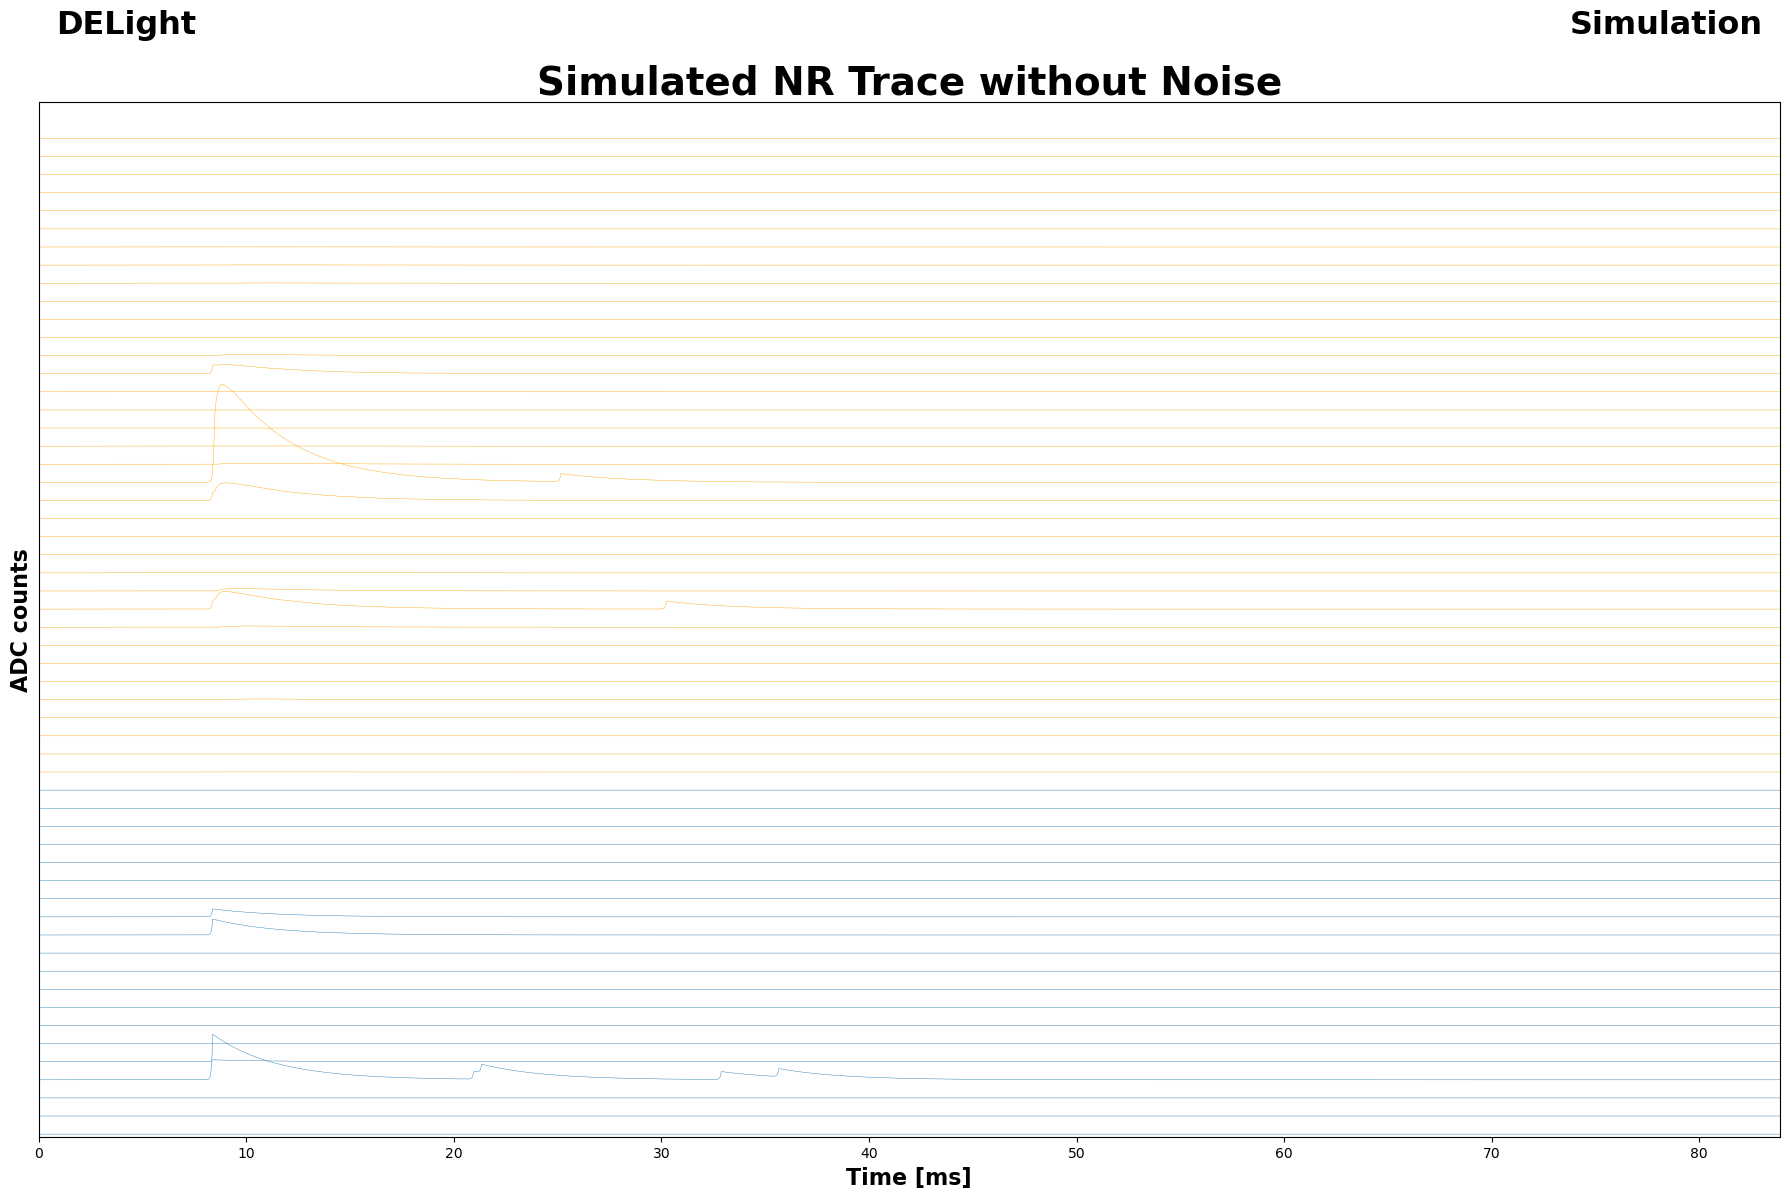

<Axes: title={'center': 'Simulated NR Trace without Noise'}, xlabel='Time [ms]', ylabel='ADC counts'>

In [12]:
plot_traces(trace, title="Simulated NR Trace without Noise")

In [13]:
import numpy as np
import h5py

# =========================
# Basic configuration
# =========================
L = 327680
T = 32768000

trace_set = np.asarray(trace)  # expected shape: (n_events, 56, L)

if trace_set.ndim != 3:
    raise ValueError(f"trace_set must have shape (n_events, 56, L), got {trace_set.shape}")

n_events, n_channels, pulse_length = trace_set.shape

if pulse_length != L:
    raise ValueError(f"Expected pulse length {L}, but trace_set has {pulse_length}")


# =========================
# Gap sampler (start-to-start gap)
# =========================
def sample_gap(L):
    u = np.random.rand()
    if u < 0.60:        # isolated
        return np.random.randint(3 * L, 10 * L + 1), "isolated"
    elif u < 0.85:      # nearby
        return np.random.randint(int(0.8 * L), 2 * L + 1), "nearby"
    else:               # overlap
        return np.random.randint(max(1, int(0.05 * L)), int(0.8 * L) + 1), "overlap"


# =========================
# 1) Generate one clean long trace (T,)
# combine all 56 channels into one pulse per event
# =========================
clean_long_trace = np.zeros(T, dtype=np.float32)
records = []

tau = np.random.randint(0, min(2 * L, T - L + 1))
prev_tau = None
event_id = 0

while tau <= T - L:
    src_idx = np.random.randint(0, n_events)

    # trace_set[src_idx] is (56, L); combine channels into one 1D pulse (L,)
    pulse_1d = trace_set[src_idx, :, :].astype(np.float32).sum(axis=0)

    amp = 1.0
    clean_long_trace[tau:tau + L] += amp * pulse_1d

    gap_to_previous = None if prev_tau is None else int(tau - prev_tau)
    overlap_with_previous = False if prev_tau is None else bool(gap_to_previous < L)

    if prev_tau is None:
        regime = "first"
    elif gap_to_previous >= 3 * L:
        regime = "isolated"
    elif gap_to_previous >= int(0.8 * L):
        regime = "nearby"
    else:
        regime = "overlap"

    records.append({
        "event_id": int(event_id),
        "source_trace_id": int(src_idx),
        "inject_index": int(tau),
        "end_index": int(tau + L),
        "amplitude_scale": float(amp),
        "gap_to_previous": int(-1 if gap_to_previous is None else gap_to_previous),
        "overlap_with_previous": overlap_with_previous,
        "regime": regime,
    })

    prev_tau = tau
    gap, _ = sample_gap(L)
    tau += gap
    event_id += 1

print("clean_long_trace shape:", clean_long_trace.shape)
print("number of injected events:", len(records))


# =========================
# 2) Generate one noise trace (T,)
# =========================
noise_raw = np.asarray(ng.generate_noise(T), dtype=np.float32)

if noise_raw.ndim == 1:
    if noise_raw.shape[0] != T:
        raise ValueError(f"1D noise must have length T={T}, got {noise_raw.shape}")
    noise_long_trace = noise_raw
    noise_mode = "1d"
elif noise_raw.ndim == 2:
    if noise_raw.shape == (n_channels, T):
        noise_long_trace = noise_raw.sum(axis=0)
        noise_mode = "sum_channels_from_(n_channels,T)"
    elif noise_raw.shape == (T, n_channels):
        noise_long_trace = noise_raw.sum(axis=1)
        noise_mode = "sum_channels_from_(T,n_channels)"
    else:
        raise ValueError(
            f"2D noise must be (n_channels, T) or (T, n_channels), got {noise_raw.shape}"
        )
else:
    raise ValueError(f"noise must be 1D or 2D, got ndim={noise_raw.ndim}")

print("noise_long_trace shape:", noise_long_trace.shape, "mode:", noise_mode)


# =========================
# 3) Construct noisy long trace (T,)
# =========================
noisy_long_trace = clean_long_trace + noise_long_trace
print("noisy_long_trace shape:", noisy_long_trace.shape)


# =========================
# 4) Save metadata
# =========================
meta_dtype = np.dtype([
    ("event_id", np.int32),
    ("source_trace_id", np.int32),
    ("inject_index", np.int64),
    ("end_index", np.int64),
    ("amplitude_scale", np.float32),
    ("gap_to_previous", np.int64),
    ("overlap_with_previous", np.bool_),
    ("regime", h5py.string_dtype(encoding="utf-8", length=16)),
])

meta_array = np.empty(len(records), dtype=meta_dtype)

for i, r in enumerate(records):
    meta_array[i] = (
        r["event_id"],
        r["source_trace_id"],
        r["inject_index"],
        r["end_index"],
        r["amplitude_scale"],
        r["gap_to_previous"],
        r["overlap_with_previous"],
        r["regime"],
    )


# =========================
# 5) Save everything in one HDF5 file (no compression)
# =========================
output_file = "long_trace_1d_all56.h5"

with h5py.File(output_file, "w") as f:
    f.create_dataset("clean_long_trace", data=clean_long_trace)
    f.create_dataset("noise_long_trace", data=noise_long_trace)
    f.create_dataset("noisy_long_trace", data=noisy_long_trace)
    f.create_dataset("metadata", data=meta_array)

    # file-level attributes
    f.attrs["n_channels_in_source"] = n_channels
    f.attrs["combine_mode"] = "sum_across_56_channels"
    f.attrs["pulse_length"] = L
    f.attrs["total_length"] = T
    f.attrs["n_events_in_library"] = n_events
    f.attrs["trace_set_shape"] = trace_set.shape
    f.attrs["noise_mode"] = noise_mode
    f.attrs["gap_definition"] = "gap_to_previous = current_start - previous_start"

print(f"Saved to {output_file}")


clean_long_trace shape: (32768000,)
number of injected events: 23
noise_long_trace shape: (32768000,) mode: 1d
noisy_long_trace shape: (32768000,)
Saved to long_trace_1d_all56.h5


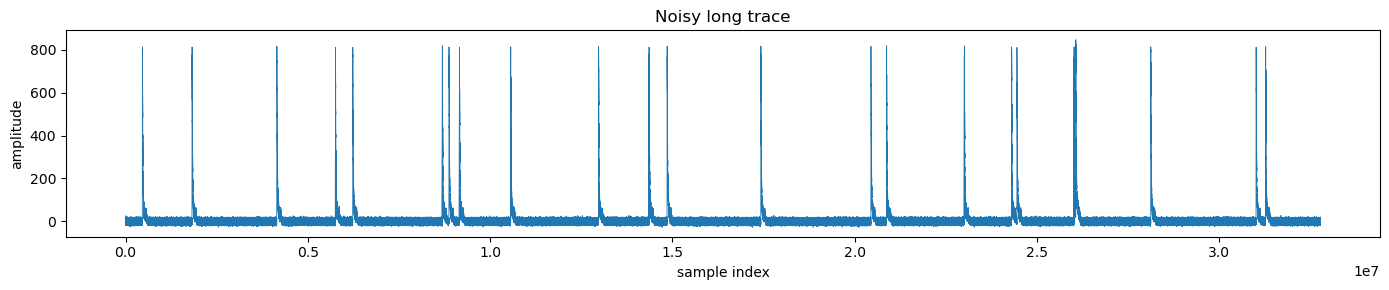

In [ ]:
# Safe whole-trace plot (downsampled)
plot_max_points = 3276800
trace_full = noisy_long_trace
step = max(1, trace_full.shape[0] // plot_max_points)

x = np.arange(0, trace_full.shape[0], step)
y = trace_full[::step]

plt.figure(figsize=(14, 3))
plt.plot(x, y, linewidth=0.6)
plt.title(f"Noisy long trace(Noise+signal)")
plt.xlabel("sample index")
plt.ylabel("amplitude")
plt.tight_layout()
plt.show()


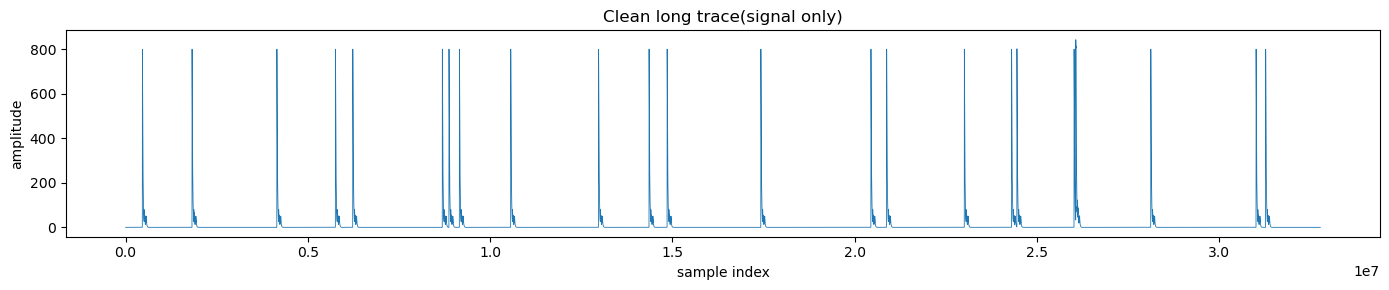

In [16]:
# Safe whole-trace plot (downsampled)
plot_max_points = 3276800
trace_full = clean_long_trace
step = max(1, trace_full.shape[0] // plot_max_points)

x = np.arange(0, trace_full.shape[0], step)
y = trace_full[::step]

plt.figure(figsize=(14, 3))
plt.plot(x, y, linewidth=0.6)
plt.title(f"Clean long trace(signal only)")
plt.xlabel("sample index")
plt.ylabel("amplitude")
plt.tight_layout()
plt.show()


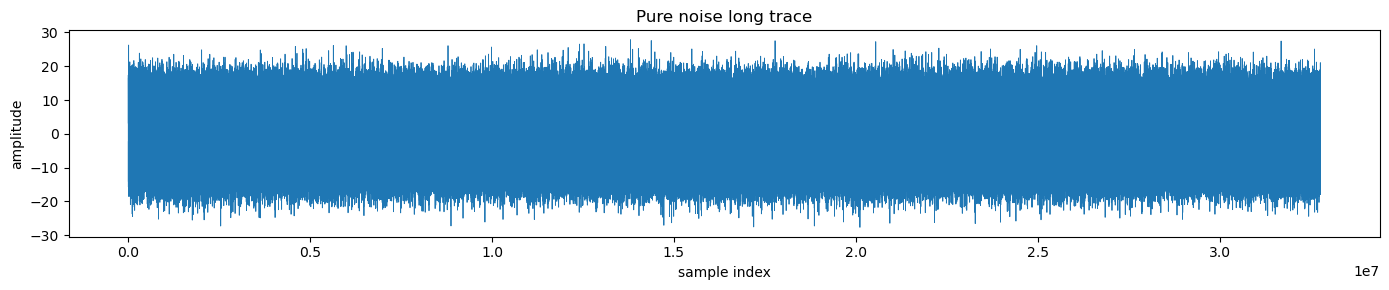

In [19]:
# Safe whole-trace plot (downsampled)
plot_max_points = 3276800
trace_full = noise_long_trace
step = max(1, trace_full.shape[0] // plot_max_points)

x = np.arange(0, trace_full.shape[0], step)
y = trace_full[::step]

plt.figure(figsize=(14, 3))
plt.plot(x, y, linewidth=0.6)
plt.title(f"Pure noise long trace")
plt.xlabel("sample index")
plt.ylabel("amplitude")
plt.tight_layout()
plt.show()


Loaded: long_trace_1d_all56.h5
Shapes: (32768000,) (32768000,) (32768000,) events: 23
Comparing event 0: source_trace_id=0, inject_index=425703, L=327680
Max abs diff: 0.0003314380543315565
RMS diff: 1.5738165250743615e-05


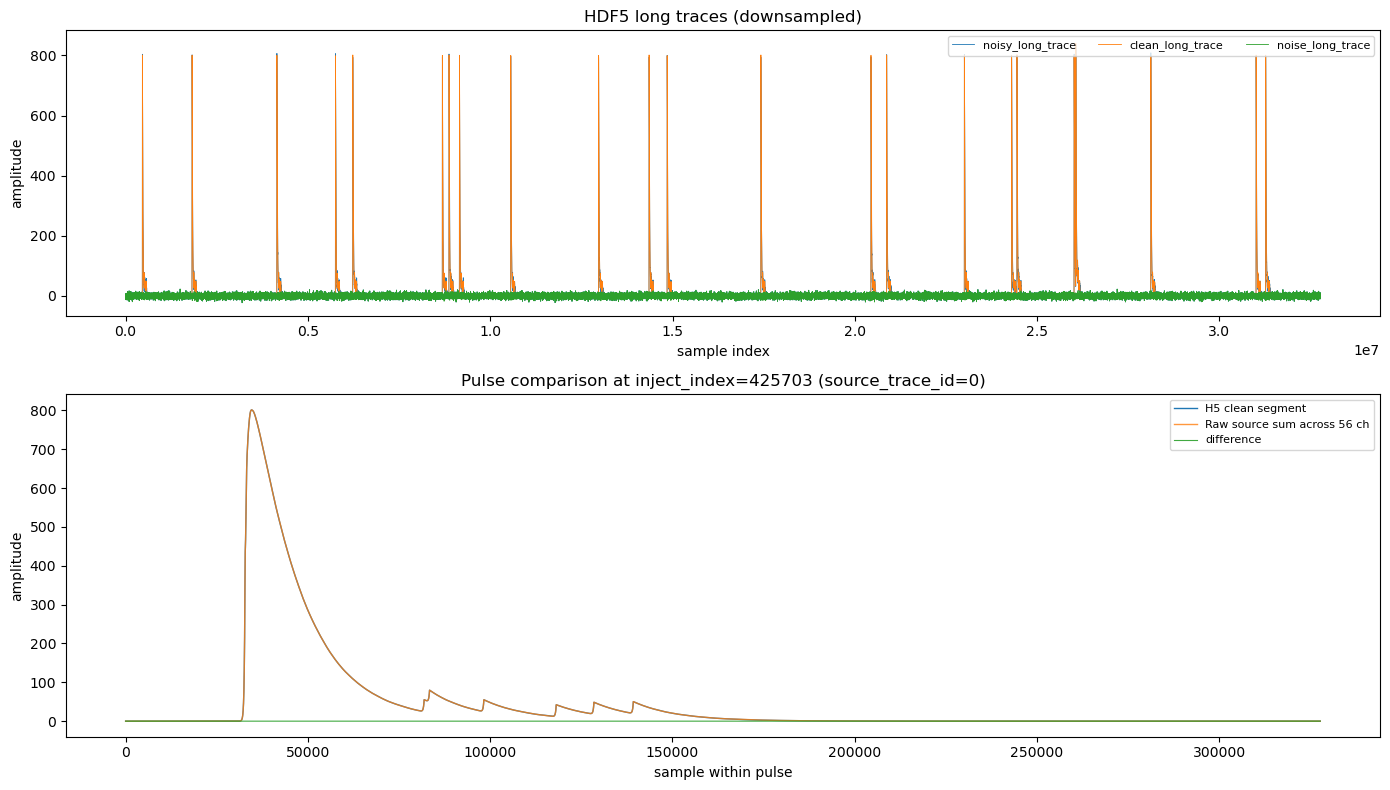

In [20]:
# Load saved HDF5 traces and compare with raw source traces from this notebook
from pathlib import Path
import numpy as np
import h5py
import matplotlib.pyplot as plt

h5_path = Path("long_trace_1d_all56.h5")
if not h5_path.exists():
    h5_path = Path("wk7") / h5_path

if not h5_path.exists():
    raise FileNotFoundError(f"Could not find {h5_path}")

with h5py.File(h5_path, "r") as f:
    clean_h5 = f["clean_long_trace"][:]
    noise_h5 = f["noise_long_trace"][:]
    noisy_h5 = f["noisy_long_trace"][:]
    meta_h5 = f["metadata"][:]

print(f"Loaded: {h5_path}")
print("Shapes:", clean_h5.shape, noise_h5.shape, noisy_h5.shape, "events:", len(meta_h5))

# Raw source traces from notebook (shape expected: n_events x 56 x L)
raw_trace_set = np.asarray(trace)
if raw_trace_set.ndim == 2:
    raw_trace_set = raw_trace_set[None, ...]
if raw_trace_set.ndim != 3:
    raise ValueError(f"Unexpected raw trace shape: {raw_trace_set.shape}")

raw_sum_set = raw_trace_set.sum(axis=1)  # n_events x L
L = raw_sum_set.shape[1]

inject_idx = meta_h5["inject_index"].astype(int)
source_idx = meta_h5["source_trace_id"].astype(int)

# Pick an injected pulse that is not overlapped by neighbors when possible
picked = 0
for i in range(len(meta_h5)):
    left_ok = (i == 0) or ((inject_idx[i] - inject_idx[i - 1]) >= L)
    right_ok = (i == len(meta_h5) - 1) or ((inject_idx[i + 1] - inject_idx[i]) >= L)
    if left_ok and right_ok:
        picked = i
        break

start = inject_idx[picked]
end = start + L
src = source_idx[picked]

if src < 0 or src >= raw_sum_set.shape[0]:
    raise IndexError(f"source_trace_id {src} out of bounds for raw trace set of size {raw_sum_set.shape[0]}")

segment_clean = clean_h5[start:end]
raw_pulse = raw_sum_set[src]

diff = segment_clean - raw_pulse
print(f"Comparing event {picked}: source_trace_id={src}, inject_index={start}, L={L}")
print("Max abs diff:", float(np.max(np.abs(diff))))
print("RMS diff:", float(np.sqrt(np.mean(diff**2))))

# 1) Full-trace view from HDF5 (downsampled)
max_points = 40000
step = max(1, len(clean_h5) // max_points)
x = np.arange(0, len(clean_h5), step)

fig, axs = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [1.0, 1.2]})
axs[0].plot(x, noisy_h5[::step], lw=0.6, label="noisy_long_trace")
axs[0].plot(x, clean_h5[::step], lw=0.6, label="clean_long_trace")
axs[0].plot(x, noise_h5[::step], lw=0.6, label="noise_long_trace")
axs[0].set_title("HDF5 long traces (downsampled)")
axs[0].set_xlabel("sample index")
axs[0].set_ylabel("amplitude")
axs[0].legend(loc="upper right", ncol=3, fontsize=8)

# 2) Pulse-level comparison: HDF5 extracted clean pulse vs raw source pulse in notebook
axs[1].plot(segment_clean, lw=1.0, label="H5 clean segment")
axs[1].plot(raw_pulse, lw=1.0, alpha=0.8, label="Raw source sum across 56 ch")
axs[1].plot(diff, lw=0.8, alpha=0.9, label="difference")
axs[1].set_title(f"Pulse comparison at inject_index={start} (source_trace_id={src})")
axs[1].set_xlabel("sample within pulse")
axs[1].set_ylabel("amplitude")
axs[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()
